In [1]:
pip install pandas matplotlib seaborn plotly openpyxl jupyter

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully! ✅")

Libraries loaded successfully! ✅


In [3]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
print("Dataset loaded! ✅")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded! ✅
Rows: 9994
Columns: 21


In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
print("Date column fixed! ✅")

Date column fixed! ✅


In [7]:
# Convert Order Date from text to a real date format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract the month and year from Order Date
df['Month-Year'] = df['Order Date'].dt.to_period('M')

print("Date column fixed! ✅")

Date column fixed! ✅


In [8]:
# Show first 5 rows of just the date columns
df[['Order Date', 'Month-Year']].head()

,Order Date,Month-Year
0,2016-11-08,2016-11
1,2016-11-08,2016-11
2,2016-06-12,2016-06
3,2015-10-11,2015-10
4,2015-10-11,2015-10


In [9]:
# Show overall summary of our number columns
df[['Sales', 'Profit', 'Quantity', 'Discount']].describe()

,Sales,Profit,Quantity,Discount
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,3.789574,0.156203
std,623.245101,234.260108,2.225110,0.206452
min,0.444000,-6599.978000,1.000000,0.000000
25%,17.280000,1.728750,2.000000,0.000000
50%,54.490000,8.666500,3.000000,0.200000
75%,209.940000,29.364000,5.000000,0.200000
max,22638.480000,8399.976000,14.000000,0.800000


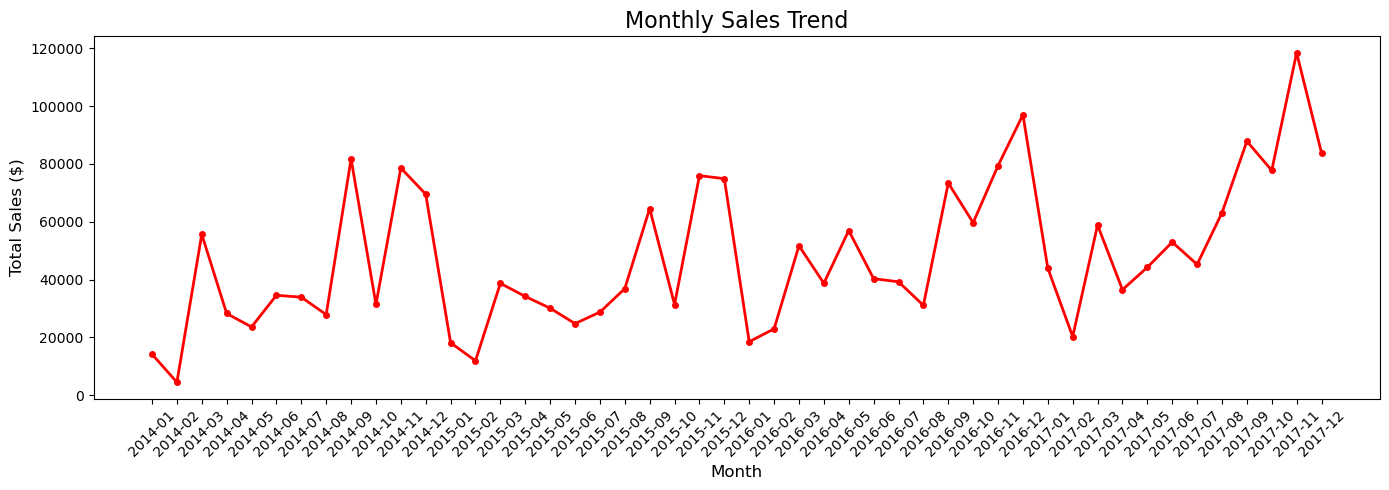

In [10]:
# Group sales by month and calculate total sales per month
monthly_sales = df.groupby('Month-Year')['Sales'].sum().reset_index()

# Convert Month-Year to string so it plots nicely
monthly_sales['Month-Year'] = monthly_sales['Month-Year'].astype(str)

# Create the chart
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Month-Year'], monthly_sales['Sales'], 
         color='red', linewidth=2, marker='o', markersize=4)

# Add titles and labels
plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

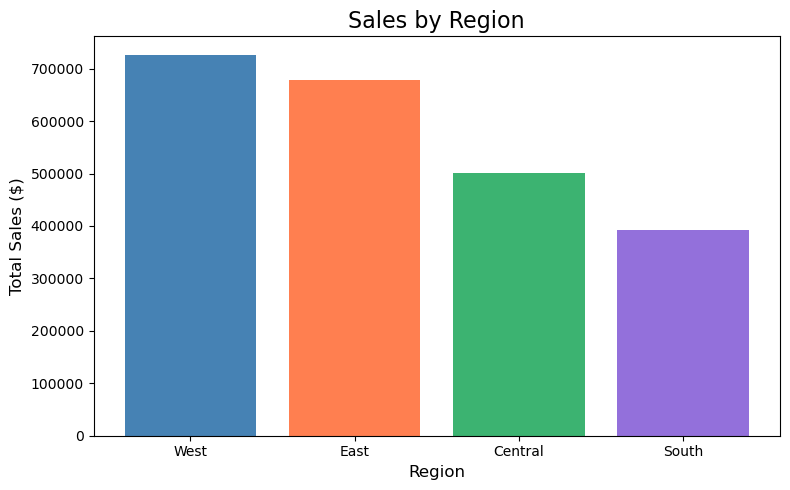

In [11]:
# Group sales by region and calculate total
regional_sales = df.groupby('Region')['Sales'].sum().reset_index()

# Sort from highest to lowest
regional_sales = regional_sales.sort_values('Sales', ascending=False)

# Create the chart
plt.figure(figsize=(8, 5))
plt.bar(regional_sales['Region'], regional_sales['Sales'],
        color=['steelblue', 'coral', 'mediumseagreen', 'mediumpurple'])

# Add titles and labels
plt.title('Sales by Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.tight_layout()
plt.show()

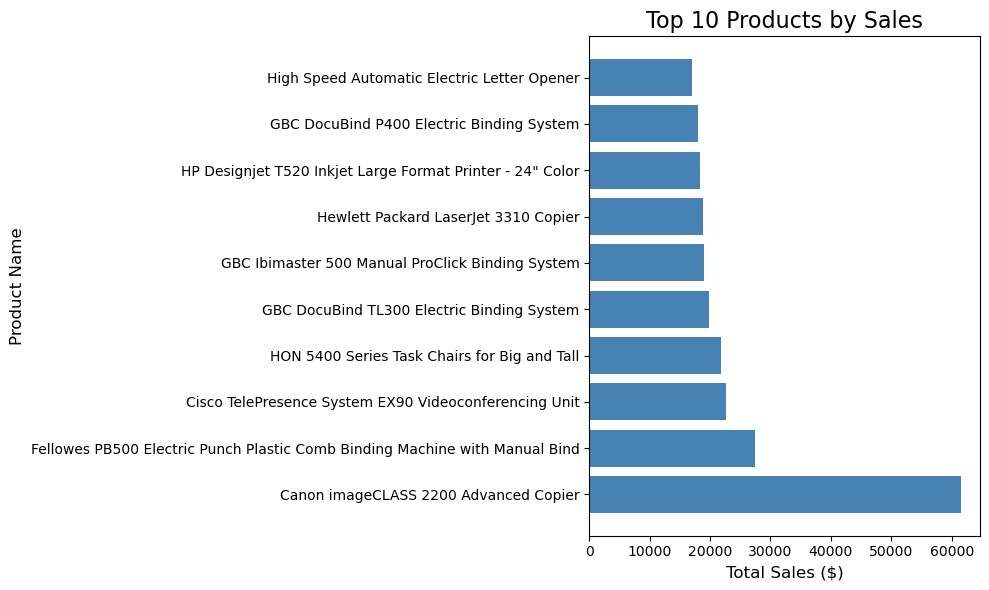

In [12]:
# Group by product name and get total sales
product_sales = df.groupby('Product Name')['Sales'].sum().reset_index()

# Sort and get top 10 only
top10_products = product_sales.sort_values('Sales', ascending=False).head(10)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(top10_products['Product Name'], top10_products['Sales'],
         color='steelblue')

# Add titles and labels
plt.title('Top 10 Products by Sales', fontsize=16)
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.tight_layout()
plt.show()

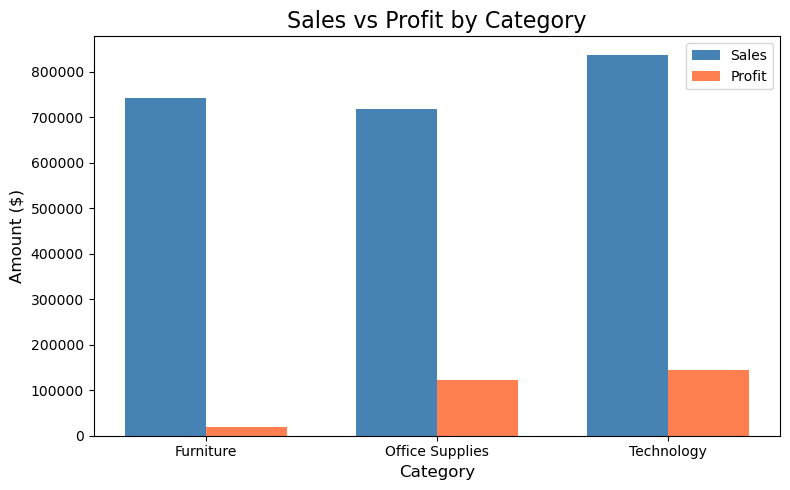

In [13]:
# Group by category and calculate total sales and profit
category_data = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()

# Create grouped bar chart
x = range(len(category_data['Category']))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x, category_data['Sales'], width, 
        label='Sales', color='steelblue')
plt.bar([i + width for i in x], category_data['Profit'], width,
        label='Profit', color='coral')

# Add titles and labels
plt.title('Sales vs Profit by Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)
plt.xticks([i + width/2 for i in x], category_data['Category'])
plt.legend()
plt.tight_layout()
plt.show()

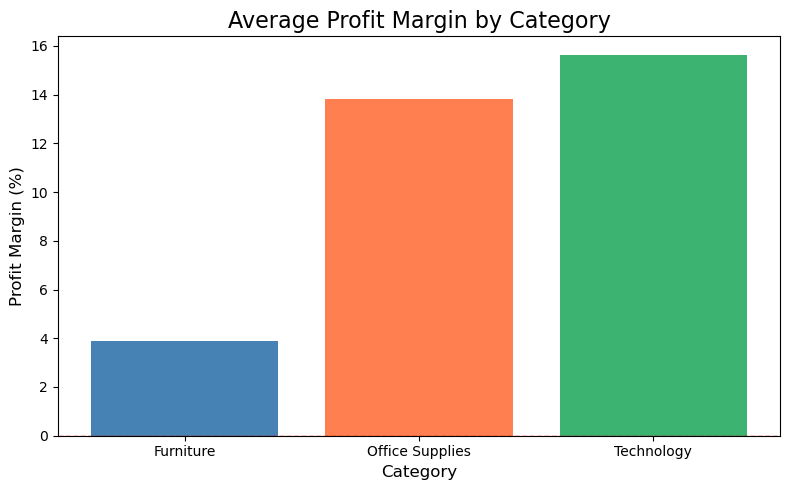

In [14]:
# Calculate profit margin for each row
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

# Group by category and get average profit margin
margin_data = df.groupby('Category')['Profit Margin'].mean().reset_index()

# Create bar chart
plt.figure(figsize=(8, 5))
plt.bar(margin_data['Category'], margin_data['Profit Margin'],
        color=['steelblue', 'coral', 'mediumseagreen'])

# Add a line at 0 to show profit vs loss
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)

# Add titles and labels
plt.title('Average Profit Margin by Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Profit Margin (%)', fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
# Calculate key business metrics
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
overall_margin = (total_profit / total_sales) * 100
best_region = df.groupby('Region')['Sales'].sum().idxmax()
worst_region = df.groupby('Region')['Sales'].sum().idxmin()
best_category = df.groupby('Category')['Profit'].sum().idxmax()
worst_category = df.groupby('Category')['Profit'].sum().idxmin()
best_month = monthly_sales.loc[monthly_sales['Sales'].idxmax(), 'Month-Year']

print("=" * 50)
print("       SALES PERFORMANCE SUMMARY")
print("=" * 50)
print(f"💰 Total Sales:        ${total_sales:,.2f}")
print(f"📈 Total Profit:       ${total_profit:,.2f}")
print(f"📊 Overall Margin:     {overall_margin:.1f}%")
print(f"🥇 Best Region:        {best_region}")
print(f"🥉 Worst Region:       {worst_region}")
print(f"✅ Most Profitable:    {best_category}")
print(f"⚠️  Least Profitable:   {worst_category}")
print(f"🗓️  Best Sales Month:   {best_month}")
print("=" * 50)

       SALES PERFORMANCE SUMMARY
💰 Total Sales:        $2,297,200.86
📈 Total Profit:       $286,397.02
📊 Overall Margin:     12.5%
🥇 Best Region:        West
🥉 Worst Region:       South
✅ Most Profitable:    Technology
⚠️  Least Profitable:   Furniture
🗓️  Best Sales Month:   2017-11
